# Step 0: Data Exploration
Count of transactions by flat type and flat model from 2021 Q1 onwards. Used to identify rare categories (1 ROOM: 41, MULTI-GENERATION: 43) that will be excluded in Step 1.

In [9]:
import pandas as pd

df = pd.read_csv(r"C:\Users\Jing Xuan\Desktop\Y3S2\DSE3101\DSE3101 Group Project\hdb_with_amenities_macro.csv")
df_filtered = df[df["month"] >= "2021-01-01"]

flat_type_counts = df_filtered["flat_type"].value_counts()
print(f"Total records from 2021 Q1 onwards: {len(df_filtered):,}")
print("\nCount by flat type:")
print(flat_type_counts.to_string())

flat_model_counts = df_filtered["flat_model"].value_counts()
print(f"Total records from 2021 Q1 onwards: {len(df_filtered):,}")
print("\nCount by flat model:")
print(flat_model_counts.to_string())

Total records from 2021 Q1 onwards: 134,488

Count by flat type:
flat_type
4 ROOM              57847
5 ROOM              32611
3 ROOM              31902
EXECUTIVE            8885
2 ROOM               3159
MULTI-GENERATION       43
1 ROOM                 41
Total records from 2021 Q1 onwards: 134,488

Count by flat model:
flat_model
Model A                   50773
Improved                  32325
New Generation            15280
Premium Apartment         14946
Simplified                 4897
Apartment                  4415
Standard                   3486
Maisonette                 3479
DBSS                       2056
Model A2                   1413
2-room                      361
Model A-Maisonette          241
Type S1                     219
Adjoined flat               210
Type S2                     105
Premium Apartment Loft       88
3Gen                         66
Terrace                      61
Multi Generation             43
Improved-Maisonette          15
Premium Maisonette        

# Step 1: Load and Clean Data
Drop nulls, drop rare flat types, drop 2020

In [11]:
import pandas as pd
import numpy as np

df_raw = pd.read_csv(r"C:\Users\Jing Xuan\Desktop\Y3S2\DSE3101\DSE3101 Group Project\hdb_with_amenities_macro.csv")
print(f"Initial shape: {df_raw.shape}")

df = df_raw.dropna()
print(f"After dropping nulls: {df.shape} (dropped {len(df_raw) - len(df)})")

# Excluded due to insufficient sample size (fewer than 50 transactions each),
# representing less than 0.1% of the dataset and falling outside the typical buyer use case.
mask_flat = ~df["flat_type"].isin(["1 ROOM", "MULTI-GENERATION"])
n_before = len(df)
df = df[mask_flat]
print(f"After dropping 1 ROOM and MULTI-GENERATION: {df.shape} (dropped {n_before - len(df)})")

# 2020 is excluded due to the COVID-19 structural break which caused abnormal market conditions
# unrepresentative of typical pricing relationships.
df["year_temp"] = pd.to_datetime(df["month"]).dt.year
n_before = len(df)
df = df[df["year_temp"] != 2020].drop(columns="year_temp")
print(f"After dropping 2020: {df.shape} (dropped {n_before - len(df)})")

df['log_resale_price_real'] = np.log(df['resale_price_real'])  # Log-transform target — preserves resale_price_real for metric computation

# Count of primary schools within 1 km — derived from pipe-separated names already in the dataset.
# Captures school density independently of nearest-school distance.
df['num_primary_1km'] = df['primary_schools_1km'].apply(
    lambda x: len(x.split('|')) if pd.notna(x) and x != '' else 0
)
print(f"num_primary_1km — mean: {df['num_primary_1km'].mean():.2f}, max: {df['num_primary_1km'].max()}")

Initial shape: (157821, 37)
After dropping nulls: (114147, 37) (dropped 43674)
After dropping 1 ROOM and MULTI-GENERATION: (114057, 37) (dropped 90)
After dropping 2020: (96796, 37) (dropped 17261)
num_primary_1km — mean: 2.99, max: 9


# Step 2: Feature Engineering
Create new columns: remaining_lease_years, floor_category, year

In [12]:
import re

def parse_remaining_lease(s):
    match = re.match(r"(\d+) years?(?: (\d+) months?)?", str(s))
    if match:
        years = int(match.group(1))
        months = int(match.group(2)) if match.group(2) else 0
        return round(years + months / 12, 2)
    return np.nan

df["remaining_lease_years"] = df["remaining_lease"].apply(parse_remaining_lease)

# Extract lower floor number from storey_range (e.g., "10 TO 12" → 10)
df["floor_lower"] = df["storey_range"].str.extract(r"^(\d+)").astype(int)
df["floor_category"] = pd.cut(
    df["floor_lower"],
    bins=[0, 5, 12, float("inf")],
    labels=["Low", "Mid", "High"],
    right=True
)

# Year for stratification only — will NOT be used as a model feature
df["year"] = pd.to_datetime(df["month"]).dt.year

# Target variable: log_resale_price_real
# RPI-adjusted prices are used so the model learns purely from flat characteristics
# rather than market-wide price appreciation over time, since year is not a model feature.
target = "log_resale_price_real"

print(df[["remaining_lease", "remaining_lease_years", "storey_range",
          "floor_lower", "floor_category", "year"]].head(10))

          remaining_lease  remaining_lease_years storey_range  floor_lower  \
23333   64 years 01 month                  64.08     01 TO 03            1   
23334   64 years 01 month                  64.08     07 TO 09            7   
23335            59 years                  59.00     04 TO 06            4   
23336  58 years 02 months                  58.17     04 TO 06            4   
23337   58 years 01 month                  58.08     01 TO 03            1   
23338  64 years 02 months                  64.17     07 TO 09            7   
23339  58 years 02 months                  58.17     04 TO 06            4   
23340   59 years 01 month                  59.08     04 TO 06            4   
23341            64 years                  64.00     07 TO 09            7   
23342  54 years 04 months                  54.33     04 TO 06            4   

      floor_category  year  
23333            Low  2021  
23334            Mid  2021  
23335            Low  2021  
23336            Low  202

# Step 3: Stratified train/test split
80/20 ratio
Stratification key: town + flat_type + year

In [13]:
from sklearn.model_selection import train_test_split

df["strat_key"] = (df["town"].astype(str) + "_" +
                   df["flat_type"].astype(str) + "_" +
                   df["year"].astype(str))

strat_counts = df["strat_key"].value_counts()
valid_keys = strat_counts[strat_counts >= 2].index
n_before = len(df)
df = df[df["strat_key"].isin(valid_keys)]
print(f"Dropped {n_before - len(df)} rows with singleton strat_key combinations. Remaining: {len(df):,}")

train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df["strat_key"])
print(f"Train size: {len(train_df):,} | Test size: {len(test_df):,}")

print("\nYear distribution (%):")
train_year = train_df["year"].value_counts(normalize=True).sort_index().rename("Train %")
test_year = test_df["year"].value_counts(normalize=True).sort_index().rename("Test %")
year_dist = pd.concat([train_year, test_year], axis=1)
print(year_dist.map(lambda x: f"{x:.2%}"))

print("\nFlat type distribution (%):")
train_flat = train_df["flat_type"].value_counts(normalize=True).rename("Train %")
test_flat = test_df["flat_type"].value_counts(normalize=True).rename("Test %")
flat_dist = pd.concat([train_flat, test_flat], axis=1)
print(flat_dist.map(lambda x: f"{x:.2%}"))

Dropped 7 rows with singleton strat_key combinations. Remaining: 96,789
Train size: 77,431 | Test size: 19,358

Year distribution (%):
     Train %  Test %
year                
2021  21.92%  21.91%
2022  19.92%  19.99%
2023  18.78%  18.77%
2024  20.62%  20.61%
2025  18.76%  18.73%

Flat type distribution (%):
          Train %  Test %
flat_type                
4 ROOM     41.87%  41.89%
3 ROOM     25.56%  25.54%
5 ROOM     23.59%  23.59%
EXECUTIVE   6.75%   6.77%
2 ROOM      2.22%   2.21%


# Step 4: Prepare Features for CatBoost

We use the same target and a similar feature set as the OLS model for fair comparison.

CatBoost can:
- handle categorical variables directly
- capture nonlinearities and interactions automatically
- avoid one-hot encoding
- avoid feature scaling

In [14]:
from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd

In [15]:
# Same target as OLS
target = "log_resale_price_real"

# Use the same comparable predictors as the OLS baseline
feature_cols = [
    "remaining_lease_years",
    "nearest_train_dist_m",
    "dist_nearest_hawker_m",
    "dist_nearest_primary_m",
    "num_primary_1km",
    "dist_nearest_park_m",
    "dist_nearest_sportsg_m",
    "dist_nearest_mall_m",
    "dist_nearest_healthcare_m",
    "flat_type",
    "town",
    "floor_category"
]

categorical_features = ["flat_type", "town", "floor_category"]

X_train = train_df[feature_cols].copy()
X_test = test_df[feature_cols].copy()

y_train = train_df[target].copy()
y_test = test_df[target].copy()

# Keep actual prices for evaluation later
y_test_actual = test_df["resale_price_real"].copy()

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("Categorical features:", categorical_features)

X_train shape: (77431, 12)
X_test shape: (19358, 12)
Categorical features: ['flat_type', 'town', 'floor_category']


In [16]:
# CatBoost needs the column indices of categorical variables
cat_feature_indices = [X_train.columns.get_loc(col) for col in categorical_features]
print("Categorical feature indices:", cat_feature_indices)

Categorical feature indices: [9, 10, 11]


# Step 5: Fit CatBoost Model

The model is trained in log-price space, just like OLS.

Early stopping is used to reduce overfitting:
- training stops when validation error stops improving
- best iteration is kept automatically

In [ ]:
cat_model = CatBoostRegressor(
    loss_function="RMSE",
    eval_metric="RMSE",
    iterations=3000,
    learning_rate=0.03,
    depth=8,
    l2_leaf_reg=5,
    random_seed=42,
    early_stopping_rounds=100,
    verbose=200
)

cat_model.fit(
    X_train,
    y_train,
    cat_features=cat_feature_indices,
    eval_set=(X_test, y_test),
    use_best_model=True
)

0:	learn: 0.3057792	test: 0.3067974	best: 0.3067974 (0)	total: 218ms	remaining: 10m 53s
200:	learn: 0.0794310	test: 0.0807338	best: 0.0807338 (200)	total: 14s	remaining: 3m 15s
400:	learn: 0.0678894	test: 0.0689811	best: 0.0689811 (400)	total: 28.9s	remaining: 3m 7s
600:	learn: 0.0634273	test: 0.0648068	best: 0.0648067 (598)	total: 43.3s	remaining: 2m 52s
800:	learn: 0.0609379	test: 0.0626753	best: 0.0626753 (800)	total: 56.6s	remaining: 2m 35s
1000:	learn: 0.0589996	test: 0.0610838	best: 0.0610838 (1000)	total: 1m 10s	remaining: 2m 20s
1200:	learn: 0.0575956	test: 0.0600089	best: 0.0600089 (1200)	total: 1m 24s	remaining: 2m 6s
1400:	learn: 0.0565278	test: 0.0592509	best: 0.0592509 (1400)	total: 1m 38s	remaining: 1m 51s
1600:	learn: 0.0556193	test: 0.0586312	best: 0.0586312 (1600)	total: 1m 52s	remaining: 1m 38s
1800:	learn: 0.0548325	test: 0.0581436	best: 0.0581436 (1800)	total: 2m 9s	remaining: 1m 25s
2000:	learn: 0.0541138	test: 0.0576954	best: 0.0576954 (2000)	total: 2m 26s	remaini

CatBoostRegressor(depth=8, early_stopping_rounds=100, eval_metric='RMSE', iterations=3000, l2_leaf_reg=5, learning_rate=0.03, loss_function='RMSE', random_seed=42, verbose=200)

In [19]:
print("Best iteration:", cat_model.get_best_iteration())
print("Best validation RMSE (log scale):", cat_model.get_best_score()["validation"]["RMSE"])

Best iteration: 2999
Best validation RMSE (log scale): 0.056387629493246536


# Step 6: Generate Predictions

Predictions are first made in log-price space, then exponentiated back to actual SGD prices for interpretation and evaluation.

In [20]:
# Predict in log-price space
y_pred_log = cat_model.predict(X_test)

# Convert back to actual price space
y_pred_actual = np.exp(y_pred_log)

# Store predictions for later diagnostics
pred_df = test_df.copy()
pred_df["pred_log_resale_price_real"] = y_pred_log
pred_df["pred_resale_price_real"] = y_pred_actual

pred_df[["resale_price_real", "pred_resale_price_real"]].head()

,resale_price_real,pred_resale_price_real
133984,415000.00,436858.811169
149133,399803.63,377294.822906
112037,628461.95,680647.309687
26490,342196.91,347859.356323
88536,627338.94,657727.049814


# Step 7: Evaluation

Metrics are computed in actual SGD price space for interpretability.

In [21]:
def mean_absolute_percentage_error(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

def linlin_loss(y_true, y_pred, a=1, b=1):
    """
    Linear-linear loss:
    - underprediction: a * |error|
    - overprediction:  b * |error|

    With a = b = 1, this becomes equivalent to mean absolute error.
    """
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    errors = y_pred - y_true
    return np.mean(np.where(errors < 0, a * (-errors), b * errors))

In [22]:
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))
mae = mean_absolute_error(y_test_actual, y_pred_actual)
r2 = r2_score(y_test_actual, y_pred_actual)
mape = mean_absolute_percentage_error(y_test_actual, y_pred_actual)
linlin = linlin_loss(y_test_actual, y_pred_actual, a=1, b=1)

print(f"CatBoost RMSE: ${rmse:,.2f}")
print(f"CatBoost MAE: ${mae:,.2f}")
print(f"CatBoost R²: {r2:.4f}")
print(f"CatBoost MAPE: {mape:.2f}%")
print(f"CatBoost Lin-Lin Loss: {linlin:,.2f}")

CatBoost RMSE: $40,465.73
CatBoost MAE: $27,771.06
CatBoost R²: 0.9647
CatBoost MAPE: 4.15%
CatBoost Lin-Lin Loss: 27,771.06


# Step 8: Feature Importance

Unlike OLS, CatBoost does not return coefficients with direct percentage interpretation.

Instead, feature importance shows which predictors contributed most to the model's predictive performance.

In [23]:
import matplotlib.pyplot as plt

importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": cat_model.get_feature_importance()
}).sort_values("importance", ascending=False)

importance_df

,feature,importance
9,flat_type,42.254323
0,remaining_lease_years,16.609832
10,town,14.289732
2,dist_nearest_hawker_m,6.129537
4,num_primary_1km,4.021523
1,nearest_train_dist_m,3.884268
11,floor_category,2.917743
8,dist_nearest_healthcare_m,2.765213
7,dist_nearest_mall_m,2.558815
6,dist_nearest_sportsg_m,2.274529


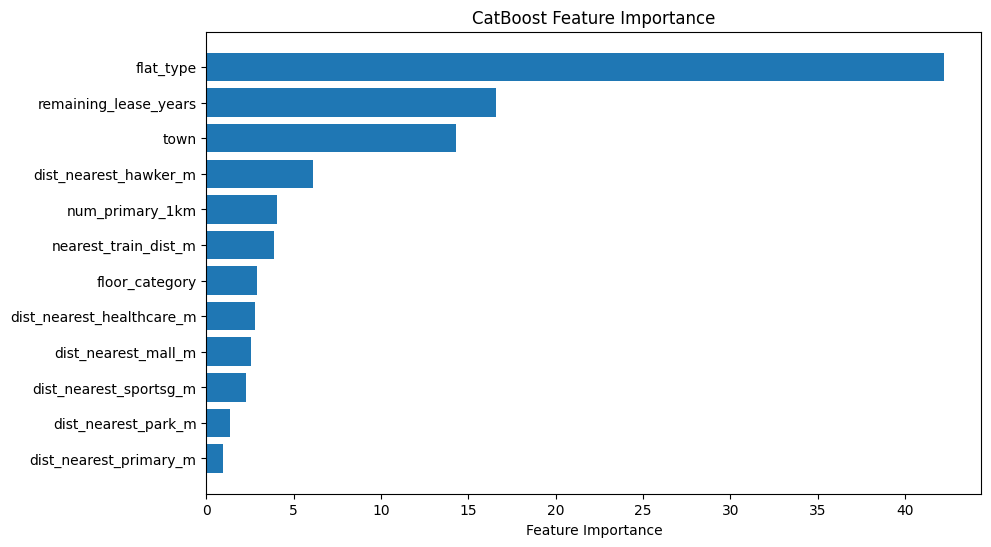

In [24]:
plt.figure(figsize=(10, 6))
plt.barh(importance_df["feature"], importance_df["importance"])
plt.gca().invert_yaxis()
plt.xlabel("Feature Importance")
plt.title("CatBoost Feature Importance")
plt.show()

# Step 9: Diagnostics

These plots help assess prediction quality and residual behaviour in actual SGD price space.

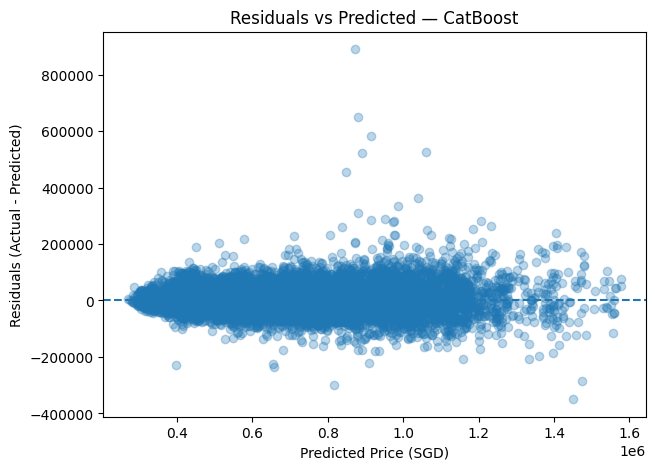

In [25]:
residuals = y_test_actual - y_pred_actual

plt.figure(figsize=(7, 5))
plt.scatter(y_pred_actual, residuals, alpha=0.3)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted Price (SGD)")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residuals vs Predicted — CatBoost")
plt.show()

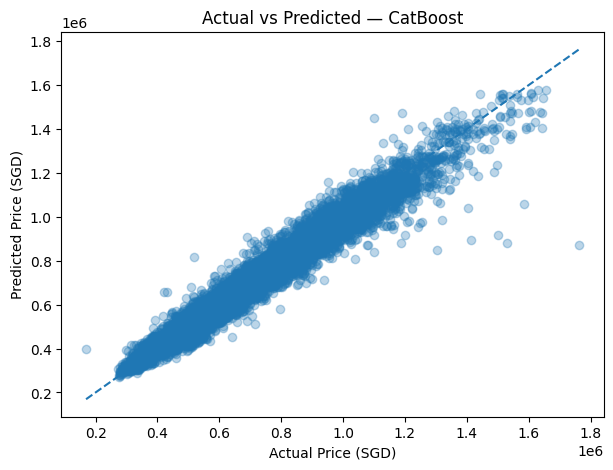

In [26]:
plt.figure(figsize=(7, 5))
plt.scatter(y_test_actual, y_pred_actual, alpha=0.3)
plt.plot(
    [y_test_actual.min(), y_test_actual.max()],
    [y_test_actual.min(), y_test_actual.max()],
    linestyle="--"
)
plt.xlabel("Actual Price (SGD)")
plt.ylabel("Predicted Price (SGD)")
plt.title("Actual vs Predicted — CatBoost")
plt.show()

# Step 10: Error by Segment

Check whether the model performs worse for certain towns or flat types.

In [27]:
segment_error = pred_df.copy()
segment_error["residual"] = segment_error["resale_price_real"] - segment_error["pred_resale_price_real"]
segment_error["abs_error"] = np.abs(segment_error["residual"])

town_error = (
    segment_error.groupby("town")
    .agg(
        mean_residual=("residual", "mean"),
        mean_abs_error=("abs_error", "mean"),
        count=("residual", "size")
    )
    .sort_values("mean_abs_error", ascending=False)
)

flat_type_error = (
    segment_error.groupby("flat_type")
    .agg(
        mean_residual=("residual", "mean"),
        mean_abs_error=("abs_error", "mean"),
        count=("residual", "size")
    )
    .sort_values("mean_abs_error", ascending=False)
)

print("Error by town:")
print(town_error)

print("\nError by flat type:")
print(flat_type_error)

Error by town:
                 mean_residual  mean_abs_error  count
town                                                 
BUKIT TIMAH        8300.435458    57603.993555     60
BISHAN             7831.781010    50559.232802    328
CENTRAL AREA        336.116844    49432.572160    171
MARINE PARADE      7400.363119    39879.313732    151
BUKIT MERAH        3776.459726    37103.422433    976
SERANGOON          3852.146362    36633.275094    442
TOA PAYOH          7491.179493    36350.813002    810
CLEMENTI           -276.551837    35251.673692    268
KALLANG/WHAMPOA    3633.956394    34948.116537    691
QUEENSTOWN         4591.123793    33695.872716    334
ANG MO KIO         3322.047660    31261.934803   1034
GEYLANG            9950.994510    31050.306926    643
PASIR RIS          -455.070178    28888.840716    683
HOUGANG             590.375846    27883.783762   1336
BUKIT PANJANG      -710.893679    27508.530935    460
BEDOK              -900.054028    27130.022243   1278
TAMPINES     

# Step 11: Save Outputs

In [28]:
import joblib

joblib.dump(cat_model, "catboost_hdb_model.pkl")
pred_df.to_csv("catboost_test_predictions.csv", index=False)

print("Saved model as catboost_hdb_model.pkl")
print("Saved predictions as catboost_test_predictions.csv")

Saved model as catboost_hdb_model.pkl
Saved predictions as catboost_test_predictions.csv
